## LSE vs Linear decoder

In this notebook we evalute the weights of the LSE and linear decoder to check whether they are more disentangled.

In [39]:
import wandb
import pandas as pd
wandb.login()
from pathlib import Path

# plotting libraries
import seaborn as sns
import matplotlib.pyplot as plt

import InterScale as interscale
from InterScale._paths import FIG_PATH
from InterScale.config import load_config
#from InterScale.pl.wandb import load_result_as_df, compute_mean_and_std, summary_df, plot_parameter_space

# Load Wandb paths

In [9]:
FIG_PATH_WANDB = Path(FIG_PATH, 'legnini23', 'disentanglement')
FIG_PATH_WANDB

PosixPath('/home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/disentanglement')

In [14]:
api = wandb.Api()
runs = api.runs("francesca-drummer/GTLongRange_Legnini23", {"group": "Linear-vs-LSE-decoder"})

In [36]:
comparison_data = []
for run in runs:
    print(run.config)
    comparison_data.append({
        'run_name': run.name,
        'decoder': run.config['model']['decoder']['type'],
        'learning_rate': run.config['optim']['lr_scheduler'],
        'final_loss': run.summary.get('val_loss'),
        'val_mse': run.summary.get('val_mse'),
        'val_r2': run.summary.get('val_r2'),  # adjust metric names
        'training_time': run.summary.get('_runtime'),
        'run_id': run.id
    })

df = pd.DataFrame(comparison_data)
df

{'model': {'loss': None, 'save': '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterScale/results/legnini23/', 'decoder': {'type': 'linear', 'hidden_dims': [256, 128], 'dropout_decoder': 0.1}, 'n_embed': 16, 'local_component': {'load': None, 'name': 'GCN', 'parameters': {'hidden_dim': 256, 'num_layers': 2, 'dropout_local': 0.1}}, 'global_component': {'load': None, 'name': 'self-attn-transformer', 'parameters': {'n_heads': 4, 'num_layers': 2, 'max_seq_len': 2000, 'dropout_global': 0.1, 'activation_func': 'relu', 'dim_feedforward': 256, 'long_range_attention': True}}}, 'optim': {'lr': 0.001, 'wd': 0.0001, 'loss': 'SmoothL1', 'seed': 44, 'n_epochs': 100, 'lr_warmup': 20, 'cross_corr': 'cell', 'lr_scheduler': 'ReduceLROnPlateau', 'lr_max_epochs': 100, 'early_stopping': True}, 'wandb': {'use': True, 'project_name': 'GTLongRange_Legnini23'}, 'dataset': {'name': 'legnini23', 'val_size': 0.2, 'h5ad_data': '/dss/dssfs03/tumdss/pn36po/pn36po-dss-0002/di93tig/Projects/A3_InterSc

,run_name,decoder,learning_rate,final_loss,val_mse,val_r2,training_time,run_id
0,legnini23_regr_node_GCN_self-attn-transformer_,linear,ReduceLROnPlateau,0.348884,0.995232,-6.120562,40,lhf70fvq
1,legnini23_regr_node_GCN_self-attn-transformer_,linear-lse,CosineWarmupScheduler,0.187849,0.360956,-3.021305,84,02nmbygu


## Load artifacts

In [30]:
lse_id = 'lhf70fvq'
linear_id = '02nmbygu'

In [50]:
import torch

api = wandb.Api()
lse_model = api.run(f"francesca-drummer/GTLongRange_Legnini23/{lse_id}")

# Get artifacts from the run
artifacts = lse_model.logged_artifacts()
print("Available artifacts:")
for artifact in artifacts:
    print(f"- {artifact.name}:{artifact.version}")

# Use the specific artifact
model_artifact = None
for artifact in artifacts:
    if artifact.type == 'model':  # or whatever type you used
        model_artifact = artifact
        break

if model_artifact:
    artifact_dir = model_artifact.download()
    model_path = f"{artifact_dir}/model.ckpt"
    checkpoint = torch.load(model_path, map_location='cpu')
else:
    print("No model artifact found")

Available artifacts:
- model-lhf70fvq:v0:v0
- run-lhf70fvq-events:v0:v0
- run-lhf70fvq-history:v0:v0


wandb:   1 of 1 files downloaded.  
/tmp/ipykernel_996413/1132249294.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location='c

In [51]:
checkpoint

{'epoch': 0,
 'global_step': 4,
 'pytorch-lightning_version': '2.5.2',
 'state_dict': OrderedDict([('module.decoder.decoder.weight',
               tensor([[ 0.1672,  0.1776,  0.2336,  ...,  0.0490, -0.2075,  0.2389],
                       [-0.2142, -0.2354,  0.1599,  ...,  0.0088,  0.0700,  0.1201],
                       [ 0.1014,  0.2499,  0.2105,  ...,  0.0923, -0.0173,  0.2451],
                       ...,
                       [ 0.2462,  0.2239,  0.1654,  ..., -0.0704, -0.0783,  0.0388],
                       [ 0.1806, -0.0119, -0.0862,  ...,  0.1208, -0.1810,  0.0967],
                       [ 0.2362,  0.0545,  0.0903,  ..., -0.1735,  0.0577,  0.2367]])),
              ('module.decoder.decoder.bias',
               tensor([ 0.1521,  0.1433, -0.2383, -0.0738, -0.1220,  0.0624,  0.1717, -0.0550,
                       -0.0990, -0.1883,  0.0195, -0.1461, -0.1698,  0.0764, -0.0461,  0.2350,
                       -0.1858,  0.0567, -0.2138,  0.0663,  0.0625, -0.1220, -0.2295, -0.0

In [45]:
artifact = lse_model.use_artifact('model:latest')  # or specific version like 'model:v0'
artifact_dir = artifact.download()

# Load the model weights
model_path = f"{artifact_dir}/model.pth"  # adjust filename as needed
checkpoint = torch.load(model_path, map_location='cpu')

CommError: You must pass a wandb.Api().artifact() to use_artifact

## Load Models from artifacts

In [43]:
lse_clse_model.config

AttributeError: '<Run francesca-drummer/GTLongRange_Legnini23/lhf70fvq (finished)>' object has no attribute 'weights'

In [42]:
interscale.model.LocalModel._setup_anndata(adata = adata, prediction_task = lse_cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
local_model = interscale.model.LocalModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = False)
interscale.model.CombinedModel._setup_anndata(adata = adata, prediction_task = cfg.dataset.prediction_task, layer_key = cfg.dataset.layer_key, sample_key_list = cfg.dataset.sample_key, prediction_obs =  cfg.dataset.prediction_obs, group_key = cfg.dataset.group_label, view_registry = False)
combined_model = interscale.model.CombinedModel.load(RESULTS_DIR, adata, cfg, local_component = True, global_component = True)

NameError: name 'adata' is not defined

## Parameter space

- Plot the performance as function of the total parameters. Can we see a stagnation at some point?
  

In [72]:
df_gnntrans_parameter.head()

,id,name,seed,state,pct_mask_nodes,radius,decoder_type,runtime_seconds,total_parameters,test_r2,test_pearson_corr,gnn_num_layers,embed_dim,trans_n_heads,trans_num_layers
0,273o3ogz,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,1493.056613,351280,0.741072,0.907089,2,128,2,4
1,7ki7esjf,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,1728.725483,883248,0.805813,0.933463,2,256,4,2
2,myiis88q,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,1751.270448,618768,0.611089,0.819073,4,32,4,2
3,ishtfjz0,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,957.564408,159568,0.757038,0.903194,4,128,4,1
4,0wsdwkms,legnini23_None_sample_1_44_gnn-transformer,None,finished,None,None,None,897.674231,408048,0.690270,0.867948,4,256,4,1


In [127]:
def plot_parameter_space(df: pd.DataFrame, 
                         metrics: str = 'test_r2', 
                         relevant_params = [],
                         save_path: str = None):

    # Apply LOWESS smoothing
    smoothed = lowess(df[metrics], df['total_parameters'], frac=0.4)  # frac controls smoothness
    # Create scatterplot with trend line
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x='total_parameters', y=metrics, data=df, label='Data Points')
    
    # Plot smoothed trend
    plt.plot(smoothed[:, 0], smoothed[:, 1], color='red', label='LOWESS Curve')
    
    # Labels and title
    plt.xlabel("Total Parameters")
    plt.ylabel(f"{metrics}")
    plt.title(f"Trend of {metrics} with Increasing Parameters")
    
    if save_path is not None:
        plt.savefig(f'{save_path}_total_parameters_vs_{metrics}.jpg', dpi=1200)
    
    plt.show()

    if len(relevant_params) > 0:
        g = sns.pairplot(df_gnntrans_parameter, x_vars=relevant_params, y_vars=['test_r2'], kind='reg', height=4)
        if save_path is not None:
            g.savefig(f'{save_path}_relevantParams_vs_{metrics}.jpg', dpi=1200)

        plt.show()

    if save_path is not None:
        print(f'Saved figures to {save_path}')

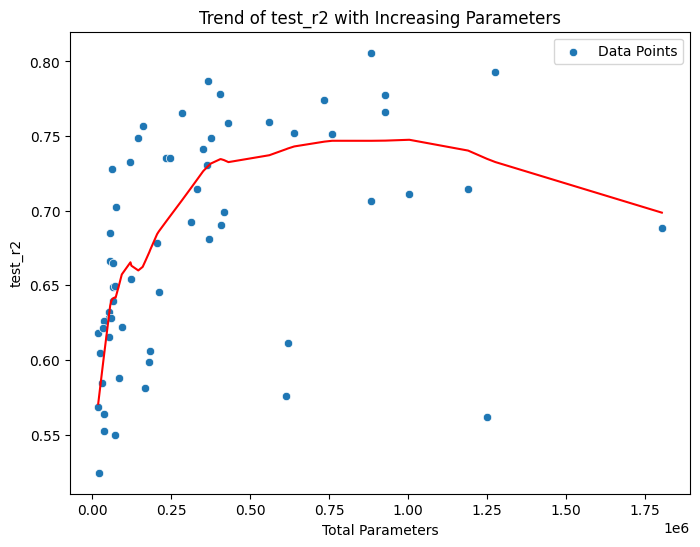

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


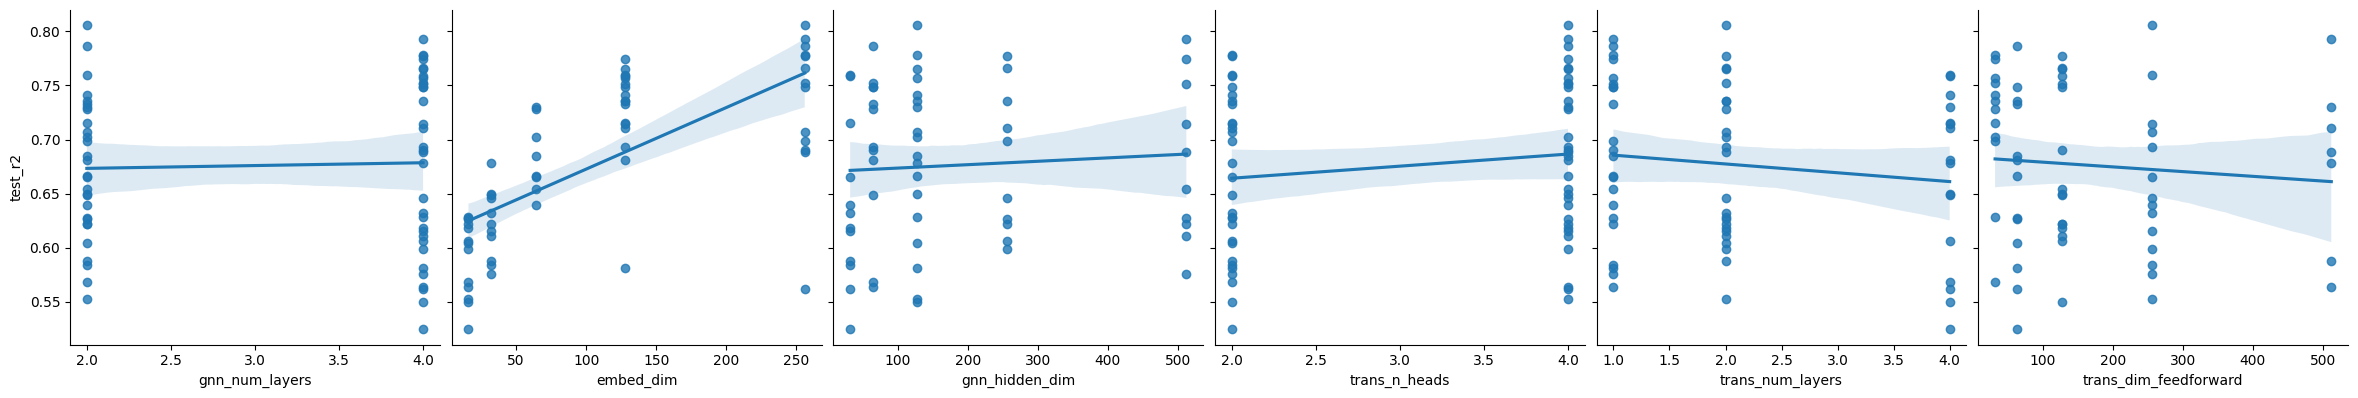

Saved figures to /home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/wandb/ghm3evf5


In [139]:
plot_parameter_space(df_gnntrans_parameter, relevant_params = ['gnn_num_layers', 'embed_dim', 'gnn_hidden_dim', 'trans_n_heads', 'trans_num_layers', 'trans_dim_feedforward'] , save_path = f'{FIG_PATH_WANDB}/{Legnini_GNNTrans_crossgene_parameter}')

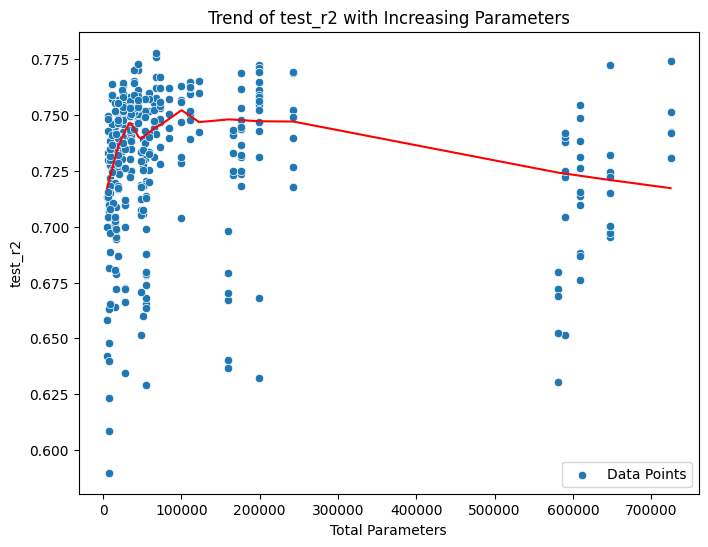

/ictstr01/groups/ml01/workspace/francesca.drummer/mamba/envs/GT_long_range_env/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


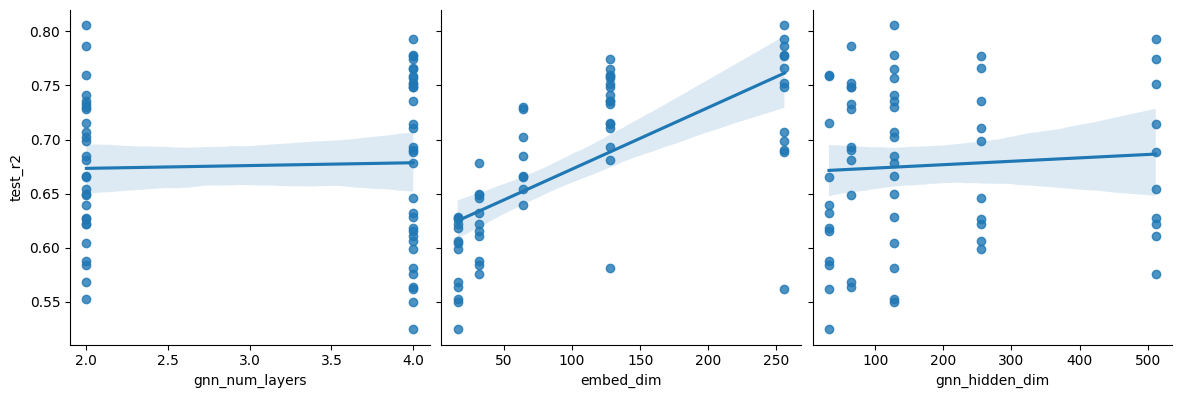

Saved figures to /home/icb/francesca.drummer/1-Projects/GT-long-range-niches/figures/legnini23/wandb/u6kgtinv


In [140]:
plot_parameter_space(df_gnn_parameter, relevant_params = ['gnn_num_layers', 'embed_dim', 'gnn_hidden_dim'] , save_path = f'{FIG_PATH_WANDB}/{Legnini_GNN_crossgene_parameter}')

## Robustness

In [7]:
df_gnn = load_result_as_df(Legnini_GNN_crossgene_experiment)
df_agg_gnn = compute_mean_and_std(df_gnn)
df_agg_gnn.head()

<Run francesca-drummer/InterScale_hyperparameter_sweep/4ppb5o5v (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/eeeq9hbz (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/fyowh8kt (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/ip93zaw3 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/7ryi7znx (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/71oenkx3 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/enjz1cmv (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/zudypyuc (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/rpokp12a (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/usntsxi0 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/k1z690gp (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/8iq1dpl0 (finished)>
<Run francesca-drummer/InterScale_hyperparameter_sweep/sxkac680 (finished)>
<Run frances

,pct_mask_nodes,radius,decoder_type,mean_test_r2,std_test_r2,mean_test_pearson,std_test_pearson,mean_run_time,std_run_time
0,0.0,0,linear,0.215774,0.428353,0.463107,0.405967,248.121250,191.150328
1,0.0,0,nonlinear,0.384891,0.373139,0.632855,0.318335,304.415826,146.998133
2,0.0,100,linear,0.200444,0.468355,0.425370,0.454796,248.669297,190.998759
3,0.0,100,nonlinear,0.386292,0.384239,0.596542,0.405699,332.892815,167.689622
4,0.0,200,linear,0.355759,0.372503,0.588741,0.360033,330.627940,178.721700


In [6]:
df_gnntrans = load_result_as_df(Legnini_GNNTrans_crossgene_experiment)
df_agg_gnntrans = compute_mean_and_std(df_gnntrans)
df_agg_gnntrans.head()

,pct_mask_nodes,radius,decoder_type,mean_test_r2,std_test_r2,mean_test_pearson,std_test_pearson,mean_run_time,std_run_time
0,0.0,0,linear,0.699093,0.046392,0.861675,0.021734,786.298800,84.134047
1,0.0,0,nonlinear,0.654882,0.096546,0.839183,0.031326,820.913805,259.135376
2,0.0,100,linear,0.647288,0.012335,0.834025,0.004402,980.877279,54.422655
3,0.0,100,nonlinear,0.669093,0.071966,0.838927,0.042680,939.264290,70.730966
4,0.0,200,linear,0.672303,0.074135,0.839908,0.047444,1000.655693,215.823289


In [16]:
def plot_robustness(df, metric = "test_r2"):
    plt.figure(figsize=(4, 6))
    sns.lineplot(
        data=df,
        x="radius",
        y=metric,
        hue="pct_mask_nodes",
        marker="o",
        palette="coolwarm",
        errorbar=("sd")  # Adds standard deviation as shaded region
    )
    
    # Formatting
    plt.xlabel("Radius")
    plt.legend(title="Pct Mask Nodes")
    if metric == "runtime_seconds":
        plt.ylim(0, 1500)  # Set y-axis range
        plt.ylabel("Mean runtime in seconds")
    else:
        plt.ylim(0, 1)  # Set y-axis range
        plt.ylabel("Mean Test R² Score")
    plt.grid(True)
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    
    # Show the plot
    plt.show()

In [9]:
df_linear_gnntrans = summary_df(df_gnntrans, "test_r2", decoder_type = "linear")

linear Decoder Summary (test_r2:
    radius  pct_mask_nodes  mean_test_r2  std_test_r2  mean_run_time  \
0        0            0.00      0.699093     0.046392     786.298800   
1        0            0.10      0.690599     0.056229    1010.803082   
2        0            0.25      0.674682     0.044393     812.447855   
3        0            0.50      0.661472     0.029549     867.981104   
4      100            0.00      0.647288     0.012335     980.877279   
5      100            0.10      0.686377     0.034877    1073.059548   
6      100            0.25      0.678638     0.051307     831.746268   
7      100            0.50      0.738730     0.009166     797.078852   
8      200            0.00      0.672303     0.074135    1000.655693   
9      200            0.10      0.673050     0.060085     840.381074   
10     200            0.25      0.666062     0.025290     791.906555   
11     200            0.50      0.682316     0.081635     808.085285   
12     300            0.00     

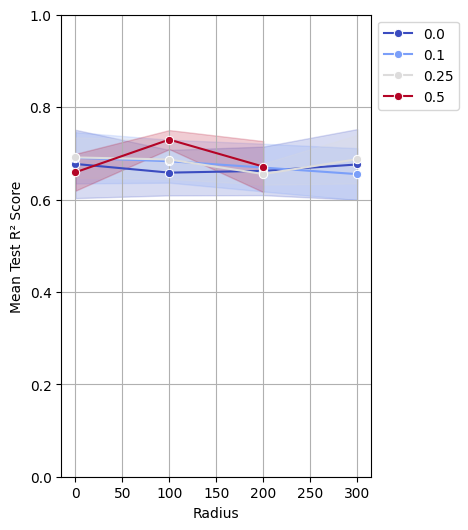

In [10]:
plot_robustness(df_gnntrans)

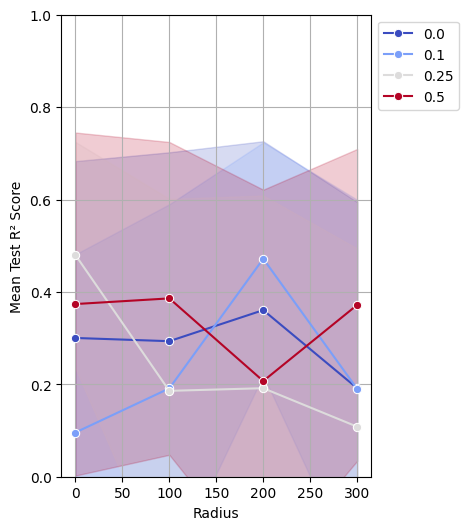

In [11]:
plot_robustness(df_gnn)

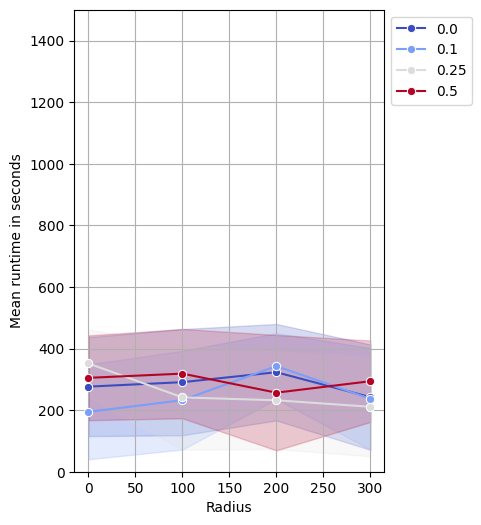

In [18]:
plot_robustness(df_gnn, 'runtime_seconds')

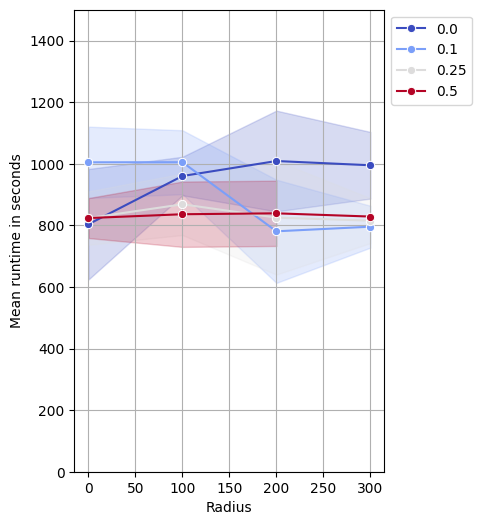

In [17]:
plot_robustness(df_gnntrans, 'runtime_seconds')